In [1]:
import os 
os.chdir("/home/ilia_linux/autolabeling_time_series_data/")
from pathlib import Path

import numpy as np

from src.utils.visuals import plot_series
from src.generation.ts_creation import *

from app.load_data import Format1_loader

In [2]:
def save_to_json(data, filepath):
    def convert(o):
        if isinstance(o, np.ndarray):
            return o.tolist()
        if isinstance(o, np.generic):
            return o.item()
        raise TypeError(f"Object of type {o.__class__.__name__} is not JSON serializable")
    
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4, default=convert)

import shutil 
def remove_result(folder_path):
    if folder_path.exists() and folder_path.is_dir():
        shutil.rmtree(folder_path)
        print(f"Папка {folder_path} удалена")
    else:
        print(f"Папка {folder_path} не существует")

# create "real" data sample

datasets: 
data format = (dimensions_num - classes num)

**TRAFFIC** 
  - Chinatown (1-2) *Классификация*. Задача по определению дня недели (2 типа выходной и будний день)
  - MelbournePedestrian (1-10)  *Классификация*. Набор данных была разработан автоматизированная система подсчета пешеходов, чтобы лучше понять активность пешеходов в муниципалитете, например, как люди используют разные места города в разное время суток. Анализ данных может помочь в принятии решений и городском планировании на будущее. Мы извлекаем данные по 10 локациям за весь 2017 год

**SPECTRO**
  - EthanolConcentration (3-4) *Классификация*. Определение уровня эталона на основе данных спектрографа 
  - EthanolLevel (1-4) *Классификация*. Определение уровня эталона на основе данных спектрографа 
  - Rock (1-4) *Классификация*. Данные содержат 70 образцов горных пород.  Каждая серия представляет собой спектральную отражательную способность горных пород в зависимости от длины волны в микронах, а не от времени. Классы соответствуют типу горных пород. - Класс 1: мрамор; - Класс 2: кварцит; - Класс 3: мрамор; - Класс 4: сланец.
  - Ham (1-2) *Классификация*. Пищевые спектрографы используются в хемометрии для классификации типов пищевых продуктов. Данные о ветчине включают результаты измерений 19 испанских и 18 французских сыровяленых окороков.

**SIMULATED**
  - ShapeletSim (1-2) *Классификация*. Сгенерированный датасет Shapelets 
  - Mallat (1-8) *Классификация*. Сгенерированный датасет для использования Wavelet преобразований

**SENSOR**
  - ItalyPowerDemand (1-2) *Классификация*. Задача по определению двух периодов ()
  - ElectricDeviceDetection (1-2) *Поиск аномалий*. Задача по выделению снимков, на которых есть електронное устройство. 
  - Car (1-4) *Классификация*. Данные представляют собой контуры четырех различных типов автомобилей, извлеченных из видеозаписей дорожного движения с использованием информации о движении. Изображения были преобразованы в трехмерную серию. Транспортные средства были классифицированы по одному из четырех классов: седан, пикап, минивэн или внедорожник
  - FaultDetectionA (1-3) *Классификация*. Задачи две определить повреждение или его отсутствие, а также локализация повреждения (внутреннее или внешнее)
  - DodgerLoopDay (1-3) 
  - BasicMotions (4-6)

**OTHER**
  - ECG200 (1-2). Generalized feature extraction for structural pattern recognition in time-series data
  - ECG5000 (1-5)

**Filtered**
  - Earthquakes (1-2) *Поиск аномалий*. тут есть проблема с нестрандартностью паттернов, однако оставил, чтобы протестировать инструменты NN. В самой задаче. Она про классификацию нежели паттернов. Сама задача правильно по сигналу определить будет ли землятресение, а не про задачу из разряда вот паттерн.
  - DucksAndGeese (1-5). Слишком длиные ряды и не очень понятно можно ли привязать к паттерн рекогнишен. 


In [2]:
all_datasets = [item for item in 'Chinatown, MelbournePedestrian, EthanolLevel, Rock, Ham, ShapeletSim, Mallat, ItalyPowerDemand, ElectricDeviceDetection, Earthquakes, Car, FaultDetectionA, DodgerLoopDay, ECG200, ECG5000, DucksAndGeese'.split(', ')]

inside_pattern = [item for item in 'Chinatown, MelbournePedestrian, Car, DodgerLoopDay, ECG200, ECG5000, EthanolLevel, Ham, ItalyPowerDemand, Mallat, Rock'.split(', ')]

full_series_patten = [item for item in 'DucksAndGeese, DodgerLoopDay, ElectricDeviceDetection, EthanolLevel, FaultDetectionA, Ham, Mallat, Rock'.split(', ')]

# ['EthanolConcentration, BasicMotions, ']
all_datasets[:4]

['Chinatown', 'MelbournePedestrian', 'EthanolLevel', 'Rock']

In [ ]:
from src.utils.parse_UCR import load_UCR
from src.utils.transform_tools import split_train_test

def load_data_UCR(dataset_name, split_ratio=0.7, random_state=25):
    X, y, metadata = load_UCR(dataset_name)
    X_train, X_test, y_train, y_test = split_train_test(X, y, split_ratio, random_state)
    X_train = X_train.squeeze(1) 
    X_test = X_test.squeeze(1)
    return X_train, X_test, y_train, y_test, metadata

from collections import defaultdict
from typing import List, Union, Dict

def sample_equal_classes(
    X: Union[List[np.ndarray], np.ndarray],
    y: Union[List[int], np.ndarray],
    samples_per_class: int,
    random_state: int = 42
) -> Dict[str, List]:
    """
    Выбирает равное количество образцов из каждого класса.

    Args:
        X (Union[List[np.ndarray], np.ndarray]): Временные ряды.
        y (Union[List[int], np.ndarray]): Метки классов.
        samples_per_class (int): Число образцов на класс.
        random_state (int): Для воспроизводимости.

    Returns:
        Dict[str, List]: {'data': ..., 'label': ...}
    """
    np.random.seed(random_state)
    
    class_to_samples = defaultdict(list)

    # Группируем ряды по классам
    for series, label in zip(X, y):
        class_to_samples[label].append(series)

    # Проверяем, что в каждом классе достаточно примеров
    min_count = min(len(samples) for samples in class_to_samples.values())
    if min_count < samples_per_class:
        raise ValueError(f"Некоторые классы содержат меньше {samples_per_class} образцов.")

    # Выбираем одинаковое число из каждого класса
    sampled_data = []
    sampled_labels = []

    for label, series_list in class_to_samples.items():
        selected = np.random.choice(len(series_list), size=samples_per_class, replace=False)
        sampled_data.extend([series_list[i] for i in selected])
        sampled_labels.extend([label] * samples_per_class)

    return {
        'data': sampled_data,
        'label': sampled_labels
    }

In [9]:
baseline_path = Path('data/OneShot_benchmark/')

for name in all_datasets:
    print(name)
    X_train, X_test, y_train, y_test, metadata = load_data_UCR(name, split_ratio = 0.3, random_state= 25)
    result = sample_equal_classes(X_train, y_train, 3, 25)
    save_to_json(result, baseline_path / f"{name}_sample.json")
    
    plot_series([item for item in result['data']], show_legend=False, save_path=baseline_path / f'pics/{name}_sample.png')
    

Chinatown
Old Classes: [1 2]
New Classes: [0 1]
MelbournePedestrian
Old Classes: [ 1  2  3  4  5  6  7  8  9 10]
New Classes: [0 1 2 3 4 5 6 7 8 9]
EthanolLevel
Old Classes: [1 2 3 4]
New Classes: [0 1 2 3]
Rock
Old Classes: [1 2 3 4]
New Classes: [0 1 2 3]
Ham
Old Classes: [1 2]
New Classes: [0 1]
ShapeletSim
Old Classes: [0 1]
New Classes: [0 1]
Mallat
Old Classes: [1 2 3 4 5 6 7 8]
New Classes: [0 1 2 3 4 5 6 7]
ItalyPowerDemand
Old Classes: [1 2]
New Classes: [0 1]
ElectricDeviceDetection
Old Classes: [0 1]
New Classes: [0 1]
Earthquakes
Old Classes: [0 1]
New Classes: [0 1]
Car
Old Classes: [1 2 3 4]
New Classes: [0 1 2 3]
FaultDetectionA
Old Classes: [0 1 2]
New Classes: [0 1 2]
DodgerLoopDay
Old Classes: [1 2 3 4 5 6 7]
New Classes: [0 1 2 3 4 5 6]
ECG200
Old Classes: [-1  1]
New Classes: [0 1]
ECG5000
Old Classes: [1 2 3 4 5]
New Classes: [0 1 2 3 4]
DucksAndGeese
Old Classes: ['black-bellied_whistling_duck' 'canadian_goose' 'greylag_goose'
 'pink-footed_goose' 'white-faced_whi

# Experiments

## Trend decomposition

In [3]:
# meta
baseline_synth = Path('data/Synthetic_data/17_06_samples')
baseline_real = Path('data/OneShot_benchmark')

dataset_path = 'quad_sin/sample1_10_4_0.json'
loader = Format1_loader()
dt = loader.load_data(baseline_synth / dataset_path)
dt

{'data': [array([-1.16389715e+01,  2.10116358e+01,  1.99780660e+01,  5.30942921e+01,
          6.30920981e+01,  6.86948013e+01,  6.88016169e+01,  8.20671142e+01,
          8.39207980e+01,  9.01753697e+01,  7.50813040e+01,  6.08573212e+01,
          7.45703935e+01,  4.61695360e+01,  4.07646082e+01,  3.67282298e+01,
          1.60550418e+01, -9.94934727e-02, -1.79328453e+01, -2.33099418e+01,
         -4.28536134e+01, -6.76780005e+01, -7.04783794e+01, -7.00015537e+01,
         -7.32378851e+01, -6.42070016e+01, -7.02538551e+01, -7.03042306e+01,
         -6.92410626e+01, -5.68686369e+01, -4.52389592e+01, -3.43515872e+01,
         -2.59974671e+01,  4.13982105e+00,  6.33470402e+00,  2.40094238e+01,
          2.68272387e+01,  5.39645860e+01,  5.03068444e+01,  8.85270227e+01,
          7.65569886e+01,  8.17172708e+01,  8.67402068e+01,  7.17001852e+01,
          9.59421404e+01,  7.24768635e+01,  4.20197056e+01,  5.63685119e+01,
          5.14049610e+01,  4.08497199e+01,  2.18150858e+00,  1.56223

In [4]:
from src.feature_extraction.manual_methods.trend_decomposition import *
from src.generation.ts_generators import *
from sklearn.metrics import root_mean_squared_error as RMSE

# meta
baseline_synth = Path('data/Synthetic_data/17_06_samples')
baseline_real = Path('data/OneShot_benchmark')

dataset_path = 'quad_sin/sample1_10_4_0.json'
loader = Format1_loader()
dt = loader.load_data(baseline_synth / dataset_path)

generator_mapping = {
    'linear_trend': linear_trend,
    "quadratic_trend": quadratic_trend,
    "exponential_trend" : exponential_trend,
    "sin_wave": sin_wave,   
    "sawtooth_wave" : sawtooth_wave,
    "harmonic_shift": harmonic_shift,
    'sawtooth_shift': sawtooth_shift  
}

save_path = Path('results/exp1')
est_comp = ['trend']
metrics = {item: [] for item in est_comp}


In [5]:
# FE_pipeline +
# Scorer 
# Segmentator 
# Cluster

In [6]:
from src.feature_extraction.fe_classes import *
from src.feature_extraction.manual_methods.trend_decomposition import *
from src.feature_extraction.manual_methods.wave_decomposition import *
from src.generation.ts_creation import TS_Block, TS_component
from src.segmentation.segmentor import PeltSegmentor, BinSegSegmentor, StumpySegmentor, KernelCPDSegmentor, WindowSegmentor, BottomUpSegmentor


row = dt['data'][0]
pipeline_single = FE_pipeline([Linregress_detrender()])
processed_data = pipeline_single.apply(row)
results = pipeline_single.get_results()
# results

2025-07-01 09:46:04.158518: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-01 09:46:04.513007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751352364.637331    3224 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751352364.675267    3224 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-01 09:46:05.026459: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

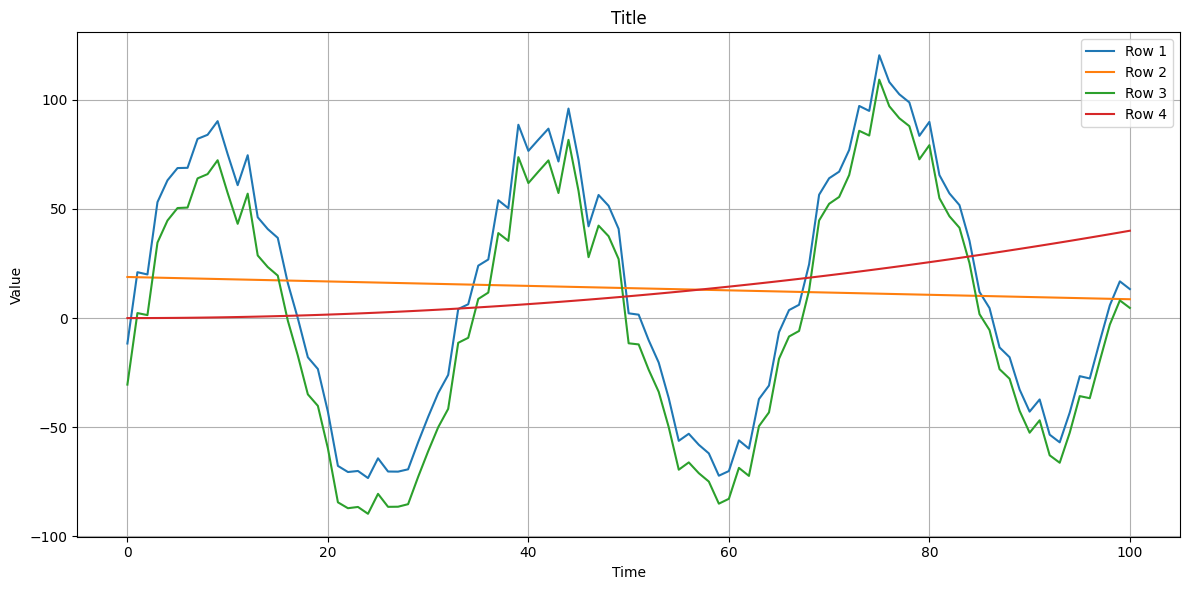

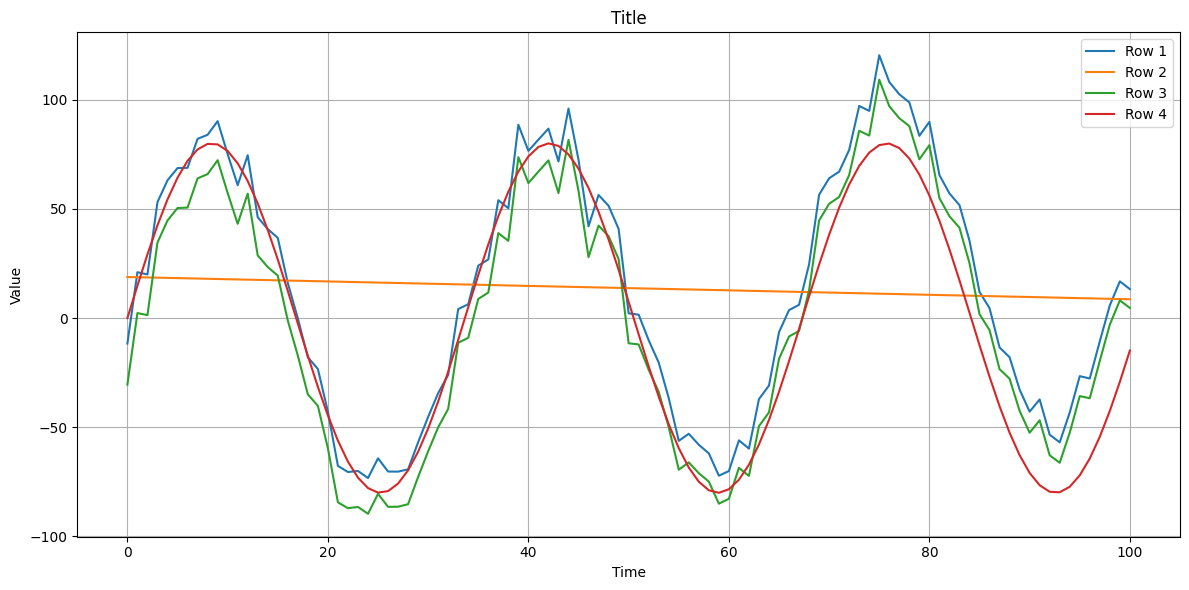

In [7]:
for k, v in dt['meta'][0].items():
    if k != 'noise':
        generator_name = v['params']['general']['generator_name']
        generator_params = v['params']['gen_params']
        restored_signal = generator_mapping.get(generator_name)(**generator_params)
        if k == 'trend':
            trend_row = restored_signal
 
        plot_series([row, results[0].component, results[0].results['detrended'], restored_signal])

/home/ilia_linux/autolabeling_time_series_data/.basic_312/lib/python3.12/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 10 is too high: all coefficients will experience boundary effects.
  warnings.warn(


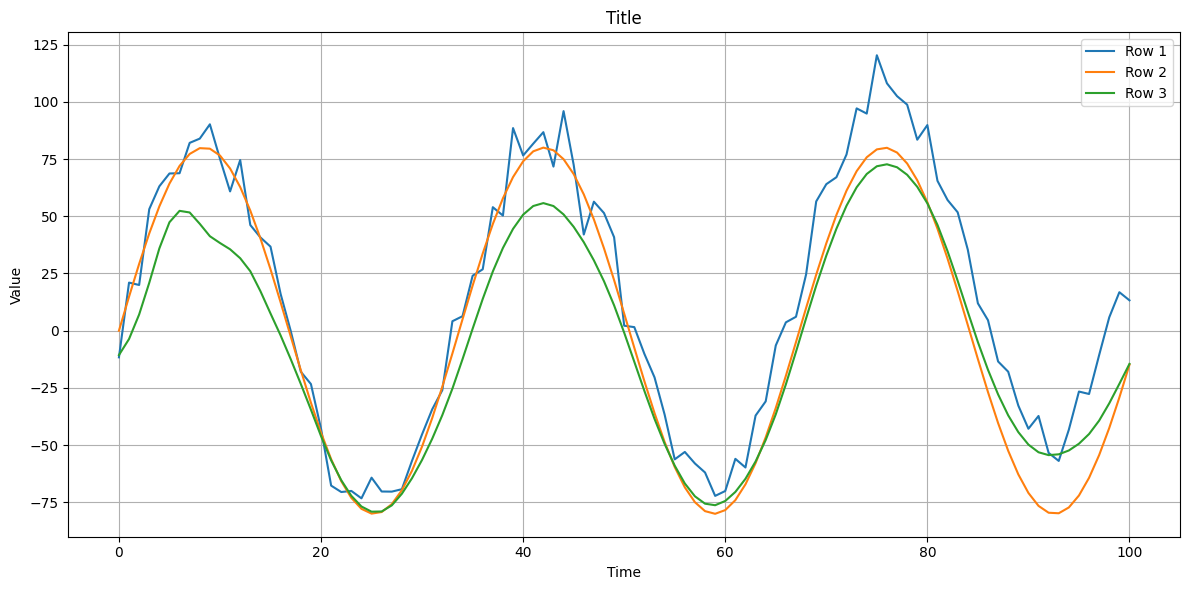

In [8]:
row = dt['data'][0]
pipeline_single = FE_pipeline([DWT_seasonality(level=10)])
processed_data = pipeline_single.apply(row)
results = pipeline_single.get_results()
# print(results[0].component)

plot_series([row, restored_signal, results[0].component])

In [9]:
row = dt['data'][0]
pipeline_single = FE_pipeline([Linregress_detrender(), DWT_seasonality(level=10)])
processed_data = pipeline_single.apply(row)
results = pipeline_single.get_results()

results[1]

FE_result(component=array([-15.97111294,  -8.91430959,   1.8653405 ,  15.80259228,
        30.93584999,  42.4701727 ,  47.50539661,  46.82546625,
        41.88434778,  36.47563284,  33.52641557,  30.80719284,
        26.93045058,  21.29059713,  12.66266431,   2.97310788,
        -6.50811168, -16.74049569, -27.48299668, -38.58273971,
       -50.02785226, -60.47105892, -69.02975199, -75.74846807,
       -80.29702906, -82.44781084, -82.24128956, -79.46578285,
       -74.26663123, -67.36864771, -59.23003186, -49.91202429,
       -39.49950118, -27.80989642, -14.86679983,  -1.47282151,
        11.62459685,  23.72316499,  34.07830439,  42.49461719,
        48.78673701,  52.63779265,  53.98977066,  52.78918338,
        49.20583494,  43.87553396,  37.2515633 ,  29.40044497,
        20.36724849,   9.92868225,  -1.94333343, -14.53133059,
       -27.17768034, -39.26731563, -50.1140519 , -59.50973835,
       -67.19760657, -72.70778531, -75.82277631, -76.3959535 ,
       -74.44565065, -70.40016962, 

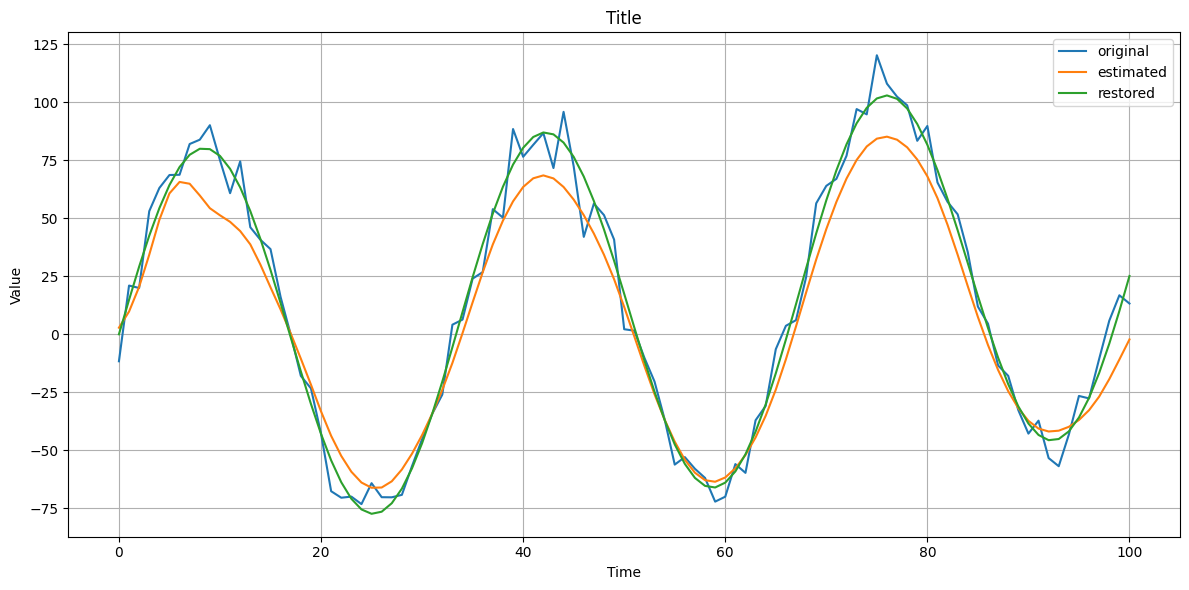

In [10]:
bl1 = TS_Block()
bl1.add_component(TS_component(results[0].component, {"general":{}, "model_name":results[0].method_name,"model_params":results[0].method_params}, 'trend'))
bl1.add_component(TS_component(results[1].component, {"general":{},"model_name":results[1].method_name,"model_params":results[1].method_params}, 'seasonality'))
bl1.add_component(TS_component(results[1].component, {"general":{},"model_name":results[1].method_name,"model_params":results[1].method_params}, 'seasonality'))

plot_series([row, bl1.get_series(), restored_signal+trend_row], ['original', 'estimated', 'restored'])

In [11]:
# Инициализация алгоритма PELT
# time_series = row
time_series = bl1.get_series()


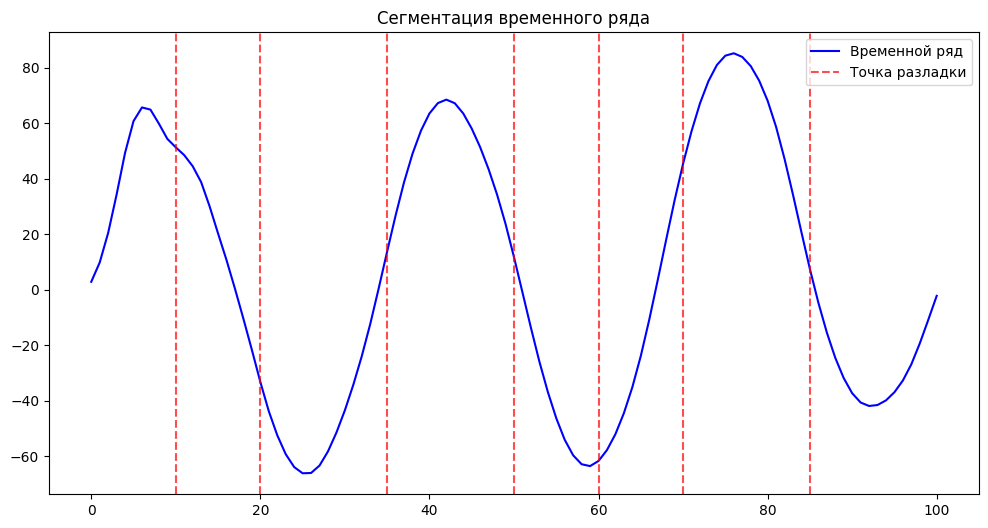

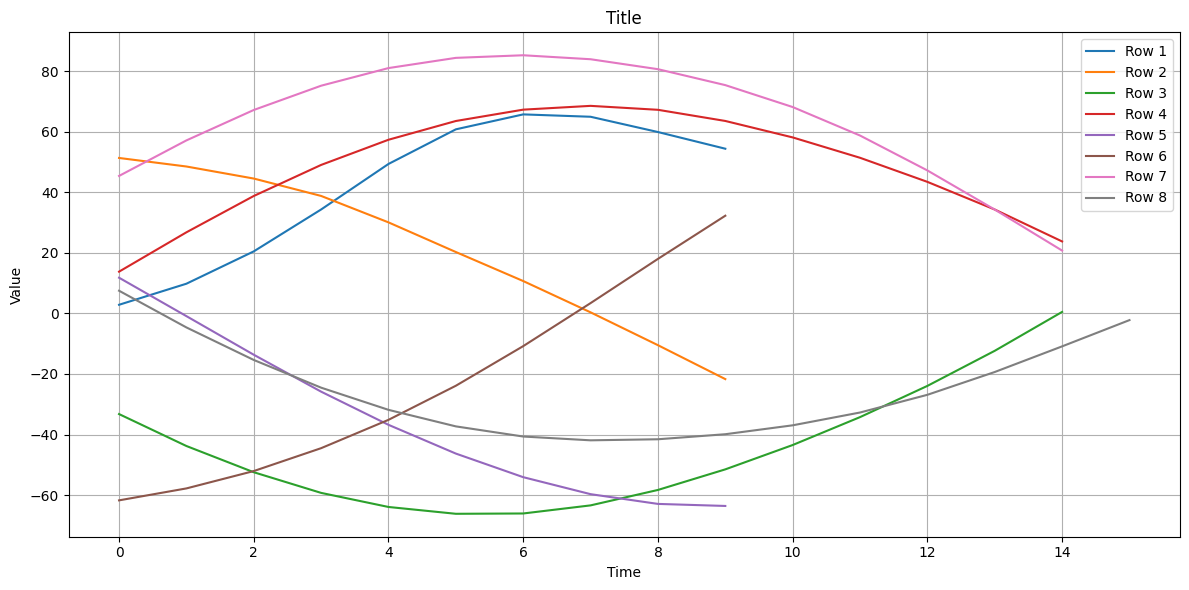

In [12]:
# Сегментация через PELT
pelt_segmentor = PeltSegmentor(model="l2")
pelt_segmentor.infer(time_series, pen=1)
pelt_segmentor.plot()
plot_series(pelt_segmentor.make_segments())

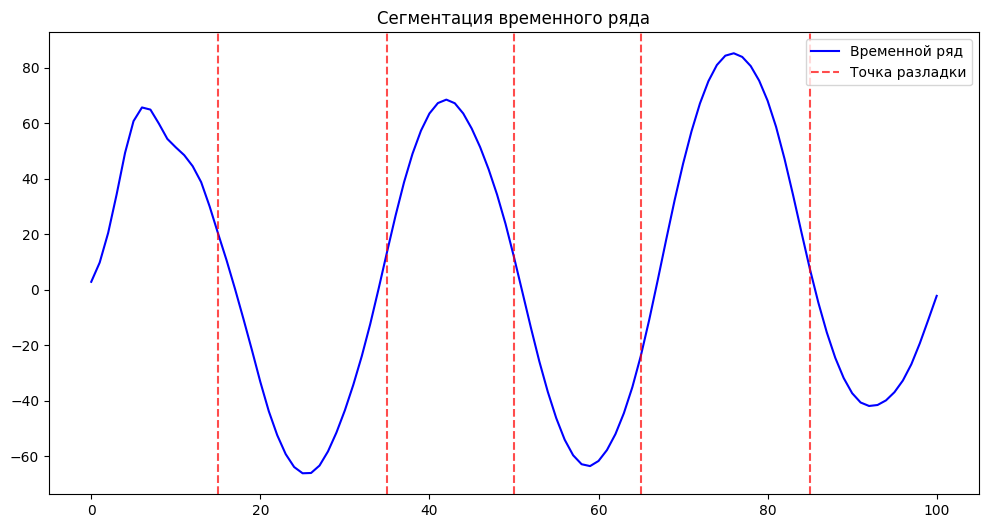

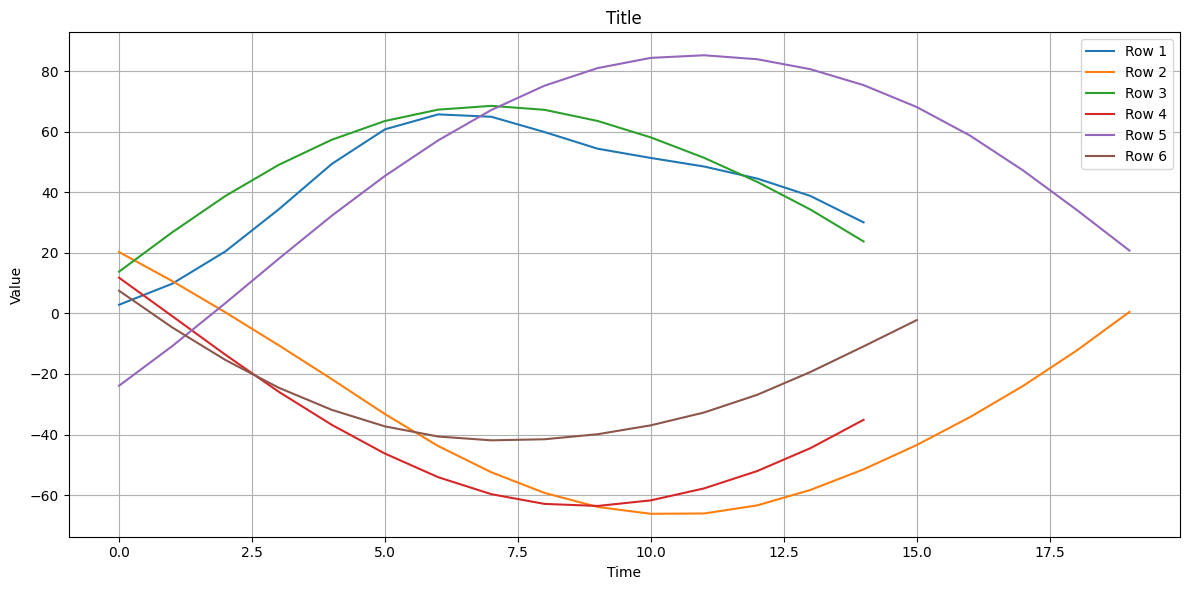

In [13]:
# Сегментация через BinSegm
pelt_segmentor = BinSegSegmentor(model="l2")
pelt_segmentor.infer(time_series)
pelt_segmentor.plot()
plot_series(pelt_segmentor.make_segments())

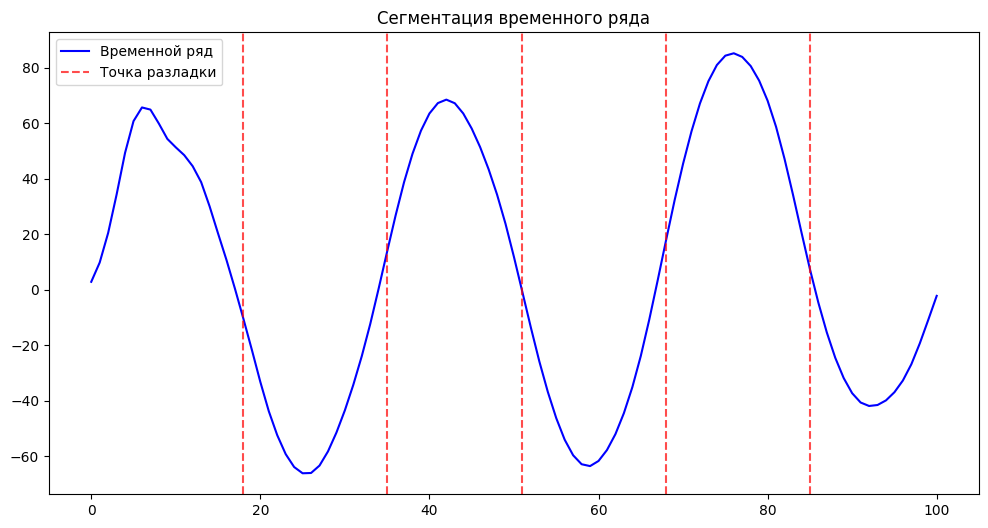

In [14]:
# Сегментация через KernelCPD
kernel_segmentor = KernelCPDSegmentor(kernel="rbf", min_size=5)
kernel_segmentor.infer(time_series, pen=5.0)
kernel_segmentor.plot()

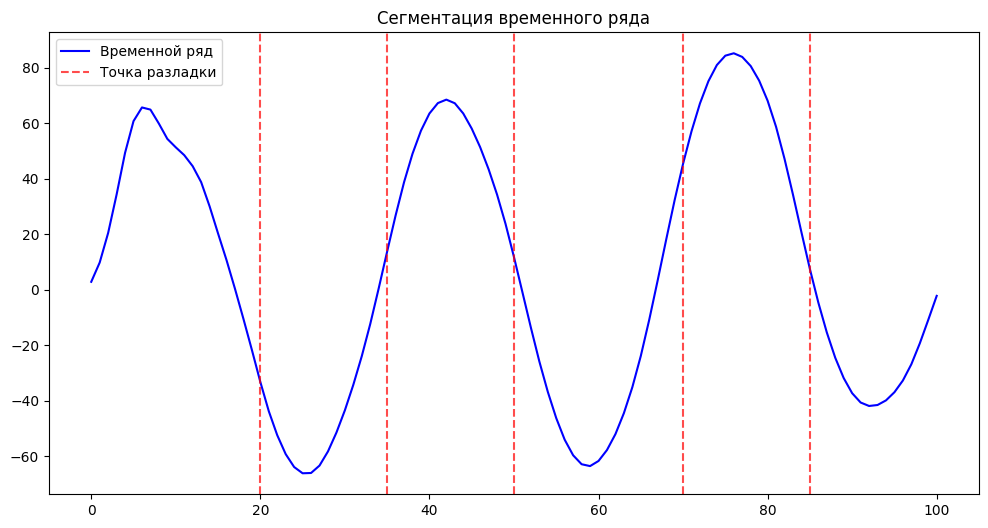

BottomUp Change Points: [20 35 50 70 85]


In [15]:
bottom_up = BottomUpSegmentor(model="l2", min_size=5)
bottom_up.infer(time_series)
bottom_up.plot()
print("BottomUp Change Points:", bottom_up.change_points)

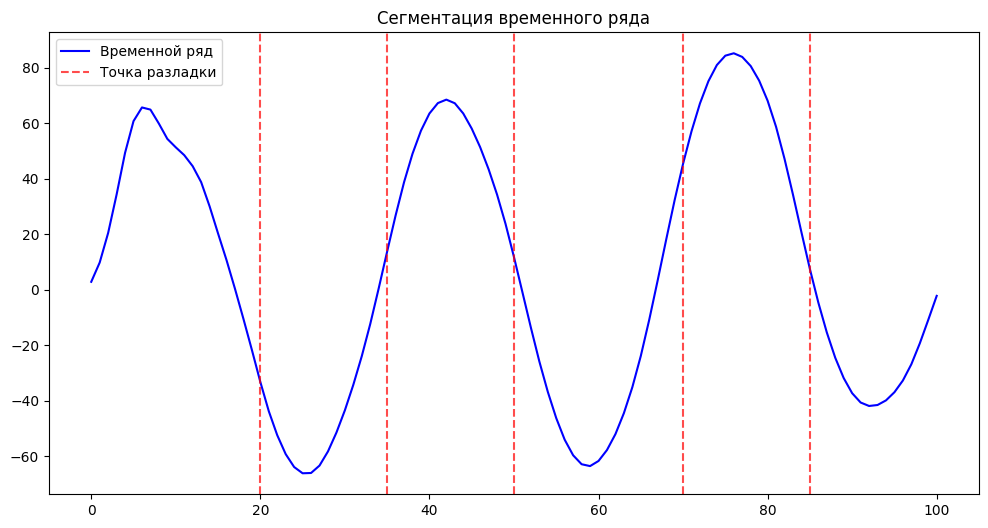

Window Change Points: [20 35 50 70 85]


In [16]:
window = WindowSegmentor(model="l2", width=10)
window.infer(time_series, pen=5.0)
window.plot()
print("Window Change Points:", window.change_points)

In [ ]:
# Сегментация через STUMPY
stumpy_segmentor = StumpySegmentor(window_size=30)
stumpy_segmentor.infer(time_series)
stumpy_segmentor.plot()

# Получение сегментов
segments = stumpy_segmentor.make_segments()
print(f"Найдено {len(segments)} сегментов.")

In [132]:
for n, row in enumerate(dt['data']):
    result = linregress_detrend(row)
    plot_series([result[0], result[1]], labels=['Detrended', 'Trend'], save_path= save_path / f'pics/result_{n}.png')
    if n == 0:
        save_config_file(result[2], save_path / f'params/result_params.yaml')
    save_config_file({str(k): str(v) for k, v in result[3].items()}, save_path / f'est_params/result_{n}.yaml')
    
    # для rmse 
    meta = dt['meta'][n].copy()
    for k, v in meta.items():
        if k == 'noise':
            pass
        
        if k in est_comp:
            generator_name = v['params']['general']['generator_name']
            generator_params = v['params']['gen_params']
            
            restored_signal = generator_mapping.get(generator_name)(**generator_params)
            plot_series([row, result[1], restored_signal], labels=['Original', f'Est. {k.capitalize()}', f'Real {k.capitalize()}'], save_path= save_path / f'pics/result_{n}_comp.png')
        
            metrics[k].append(np.round(RMSE(restored_signal, result[1]), 5))

metrics = {k:str(v) for k,v in metrics.items()}

save_config_file(metrics, 'results/exp1/result_metrics.yaml')
plot_series([linregress_detrend(row)[1] for n, row in enumerate(dt['data'])], show_legend=False, plot_title='Trends', save_path= save_path / f'pics/trends.png')


In [ ]:
# mlflow server --backend-store-uri ".backend" --default-artifact-root ".runs" --host localhost --port 5000
import mlflow
import shutil
import ast

experiment_dir = Path("results/exp1")

# Устанавливаем соединение с MLflow сервером
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("linregress_detrend")

# Загружаем общий файл параметров
params_file = save_path / "params/result_params.yaml"
params = load_config_file(params_file)

with mlflow.start_run():

    # --- 1. Логируем общие параметры ---
    def log_nested_params(d, prefix=""):
        for key, value in d.items():
            if isinstance(value, dict):
                log_nested_params(value, prefix=f"{prefix}{key}.")
            else:
                try:
                    mlflow.log_param(f"{prefix}{key}", value)
                except:
                    mlflow.log_param(f"{prefix}{key}", str(value))

    log_nested_params(params, prefix="params.")

    # --- 2. Логируем графики и метрики ---
    est_params_paths = sorted(save_path.glob("est_params/*.yaml"))
    metrics_path = save_path / "result_metrics.yaml"

    metric_means = {}

    # Читаем метрики
    metrics = {k:ast.literal_eval(v) for k,v in load_config_file(metrics_path).items()}

    # Логируем средние метрики
    for comp_name, values in metrics.items():
        mean_value = sum(values) / len(values) if values else float('nan')
        mlflow.log_metric(f"mean_{comp_name}_rmse", mean_value)
        metric_means[comp_name] = mean_value

    # --- 3. Логируем графики ---
    mlflow.log_artifacts(save_path / "pics", artifact_path="pics")

    # --- 4. Логируем YAML-файлы ---
    mlflow.log_artifact(save_path / "result_metrics.yaml", artifact_path="metrics")
    mlflow.log_artifact(save_path / "params/result_params.yaml", artifact_path="params")
    mlflow.log_artifacts(save_path / "est_params", artifact_path="est_params")

    # --- 5. Теги ---
    mlflow.set_tag("method", "linregress_detrend_component_recovery")
    mlflow.set_tag("dataset", dataset_path)

print("✅ Эксперимент успешно залогирован в MLflow")

🏃 View run powerful-loon-428 at: http://localhost:5000/#/experiments/982712660309993446/runs/fc994a0bc0494f368a6533bdc830bced
🧪 View experiment at: http://localhost:5000/#/experiments/982712660309993446
✅ Эксперимент успешно залогирован в MLflow


In [134]:
remove_result(save_path)

Папка results/exp1 удалена


## Seasonality decomposition

## Shift / anomaly detection

## Noise estimation